## Problem-1

Design a system for a library. Include classes for `Book`, `Patron`, and `Library`.

- The `Book` class should have attributes for title, author, ISBN, and a method `is_available()` that returns `True` if the book is not currently checked out and `False` otherwise. It should also have a method `check_out()` that marks the book as checked out and a method `check_in()` that marks it as available.
- The `Patron` class should have attributes for name and patron ID and a method `borrow_book(book)` that associates a book with the patron.
- The `Library` class should have a collection of `Book` objects and `Patron` objects. It should have methods to `add_book(book)`, `add_patron(patron)`, `lend_book(book, patron)`, and `return_book(book)`. The `lend_book` method should only allow a book to be lent if it's available and the patron exists in the library.


Test your implementation.

In [26]:
class Book:
    def __init__(self, title,author,isbn):
        self.title=title
        self.author=author
        self.isbn=isbn
        self._available= True
    def is_available(self):
        return self._available  
      
    def check_out(self):
        self._available = False
    
    def check_in(self):
         self._available = True
    
class Patron:
    def __init__(self,name, patron_id):
        self.name=name
        self.patron_id=patron_id
        self.borrowed_books=[]
    def borrow_book(self,book):
        self.borrowed_books.append(book)

class Library:
    def __init__(self):
        self.books={}
        self.patrons={}
    def add_book(self,book):
        self.books[book.isbn]=book
    def add_patron(self, patron):
        self.patrons[patron.patron_id]=patron

    def lend_book(self,isbn,patron_id):
        book=self.books.get(isbn)
        patron=self.patrons.get(patron_id)

        if book and patron and book.is_available():
            book.check_out()
            patron.borrow_book(book)
            return True
        return False
    def return_book(self,isbn):
        book=self.books.get(isbn)
        if book:
            book.check_in()
            return True
        return False
    
new_library=Library()
book1=Book("wings_of_fire","abdul_kalam","akasa1121")
book2=Book("testbook","testauthor","akasa1123")
new_library.add_book(book1)
new_library.add_book(book2)
patron1=Patron("Ramesh", 14541)
patron2=Patron("Suresh", 14542)
new_library.add_patron(patron1)
new_library.add_patron(patron2)


print("\n lending book wings of fire to Sandeep ") ## not patron hence result is flase ##
new_library.lend_book("akasa1123",14543)




 lending book wings of fire to Sandeep 


False

In [38]:

print("\n lending book wings of fire to Ramesh ") ## patron and book exist in library result true##
new_library.lend_book("akasa1121",14541)


 lending book wings of fire to Ramesh 


True

In [ ]:
new_library.lend_book("akasa1121",14542) ## test for book not in librabry as it is lended to ramesh hence suresh did not get it 

False

In [37]:
## return book 
new_library.return_book("akasa1121")
if True:
    print( "sucessfully returned")
else :
    print( "not borrowed from library ")

sucessfully returned


## Problem-2

Create an base class `Shape` with an method `area()` and another method `perimeter()`. Then, create classes `Rectangle` and `Circle` that inherit from `Shape` and implement the `area()` method. The `perimeter()` method in `Shape` should raise a `NotImplementedError`. Implement the `perimeter()` method in `Rectangle` and `Circle`.

Test your implementation.

In [67]:
import math
class Shape:
    def area(self):
        raise NotImplementedError("Subclasses must implement the 'area' method")
    def perimeter(self):
        raise NotImplementedError("Subclasses must implement the 'perimeter' method")
    

class Rectangle(Shape):   
    def __init__(self,length,height):
        self.length = length
        self.height = height

    def area(self):
        return self.length * self.height 
    def perimeter(self):
        return 2*(self.length + self.height)
class Circle (Shape):
    def __init__(self,radius):
        self.radius = radius
    def area(self):
        return math.pi * self.radius **2
    def perimeter(self):
        return 2 * math.pi * self.radius 
    


In [76]:
circle = Circle(10)
    
print(f"Circle - Area: {circle.area()}, Perimeter: {circle.perimeter():.2f}")

rectangle= Rectangle(10,10)
print(f"Rectangle - Area: {rectangle.area()}, Perimeter: {rectangle.perimeter():.2f}")



Circle - Area: 314.1592653589793, Perimeter: 62.83
Rectangle - Area: 100, Perimeter: 40.00


## Problem-3

Design a system to model different types of employees in a company. There should be a base `Employee` class with attributes for `name` and `employee_id`. Create two subclasses: `SalariedEmployee` with an attribute for `monthly_salary` and a method `calculate_paycheck()` that returns the monthly salary, and `HourlyEmployee` with attributes for `hourly_rate` and `hours_worked`, and a `calculate_paycheck()` method that returns the total pay for the week. Demonstrate creating instances of both employee types and calling their `calculate_paycheck()` methods.

Test your implementation.

In [ ]:
class Employee:
    def __init__(self, name, employee_id):
        self.name = name
        self.employee_id = employee_id

class SalariedEmployee(Employee):
    def __init__(self, name, employee_id, monthly_salary):
        super().__init__(name, employee_id)
        self.monthly_salary = monthly_salary

    def calculate_paycheck(self):
        return self.monthly_salary

class HourlyEmployee(Employee):
    def __init__(self, name, employee_id, hourly_rate, hours_worked):
        super().__init__(name, employee_id)
        self.hourly_rate = hourly_rate
        self.hours_worked = hours_worked

    def calculate_paycheck(self):
        return self.hourly_rate * self.hours_worked


In [5]:
emp1 = SalariedEmployee("Rao", "S101", 8000.00)
emp1.calculate_paycheck()

8000.0

In [6]:
emp2 = HourlyEmployee("Bob", "H101", 25.00, 40)
emp2.calculate_paycheck()

1000.0

## Problem-4

Design a class `polynomial` of one variable which will have attributes `degree`, a positive integer and `coefficients`, a list of floating point numbers. 
`degree` means the highest power of the variable and `coefficients` are the coefficient of individual terms.

A polynomial of degree `n` has `n+1` coefficients. 

- Example-1:
$$ 3x^4 + 5x^3 + x^2 + 9x + 10 $$
This is a polynomial of degree 4 and coefficients are [3, 5, 1, 9, 10].

- Example-2: (some coefficients could be zero)
$$ 0.7x^3 + 2.5x $$
Here the degree of polynomial is 3 and coefficients are [0.7, 0, 2.5, 0].

A polynomial of degree zero is just a constant value. 

In the `polynomial` class, you need to implement the following methods:
- `evaluate(x)` which will evaluate the polynomial for a given value of the variable x.
- `plot([x1, x2])` this will plot the polynomial for a given range of x1 to x2 of the variable.
- `derivative(x)` This will evaluate the derivative (differentiation) of the polynomial for a given value of the variable x.
- `plot_derivative([x1, x2])` this will plot the derivative of the polynomial for a given range of x1 to x2 of the variable.

The class should have basic checks, such that the number of coefficients provided by the user should be degree + 1 and the degree should be a positive integer. 

Test your implementation. 

In [23]:
import matplotlib.pyplot as plt
import numpy as np

class polynomial:
    def __init__(self, degree, coefficients):
        """
        degree: positive integer representing highest power.
        coefficients: list of floats from highest degree term to constant.
        """
        self.degree = degree
        self.coefficients = coefficients
        
        # Validation: A degree n polynomial needs n+1 coefficients
        if len(self.coefficients) != self.degree + 1:
            raise ValueError(f"A degree {self.degree} polynomial requires {self.degree + 1} coefficients.")

    def evaluate(self, x):
        """Calculates p(x) using Horner's method for efficiency."""
        result = 0
        for coef in self.coefficients:
            result = result * x + coef
        return result
    def plot(self, x_range):
        """Plots the polynomial over [x1, x2]."""
        x = np.linspace(x_range[0], x_range[1], 400)
        y = [self.evaluate(val) for val in x]
        
        plt.plot(x, y, label='Polynomial')
        plt.title(f'Polynomial of Degree {self.degree}')
        plt.xlabel('x')
        plt.ylabel('p(x)')
        plt.grid(True)
        plt.legend()
        plt.show()
        
    def _get_derivative_coeffs(self):
        """Internal helper to calculate derivative coefficients."""
        der_coeffs = []
        for i, coef in enumerate(self.coefficients[:-1]):
            power = self.degree - i
            der_coeffs.append(coef * power)
        return der_coeffs

    def derivative(self, x):
        """Evaluates p'(x) at a specific value."""
        if self.degree == 0: return 0
        
        der_coeffs = self._get_derivative_coeffs()
        result = 0
        # Horner's method on derivative coefficients
        for coef in der_coeffs:
            result = result * x + coef
        return result

    def plot_derivative(self, x_range):
        """Plots p'(x) over [x1, x2]."""
        x = np.linspace(x_range[0], x_range[1], 400)
        y = [self.derivative(val) for val in x]
        
        plt.plot(x, y, color='red', label="Derivative p'(x)")
        plt.title('Derivative of Polynomial')
        plt.xlabel('x')
        plt.ylabel("p'(x)")
        plt.grid(True)
        plt.legend()
        plt.show()
    


polynomial= 424
derivative= 474


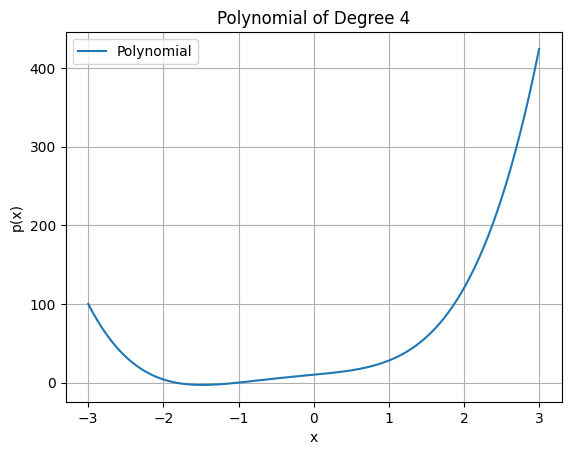

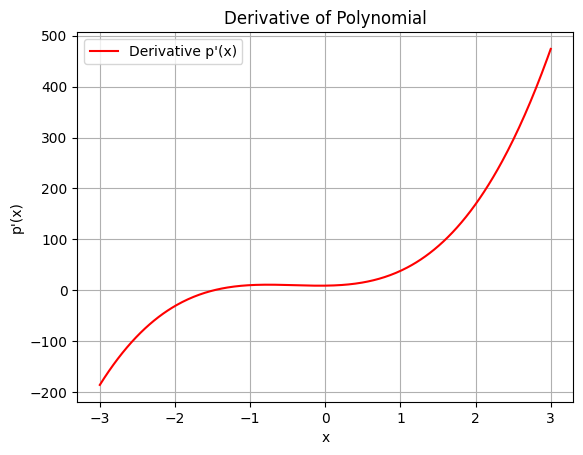

In [24]:
p1=polynomial(4,[3,5,1,9,10])
print ("polynomial=",p1.evaluate(3))
print ("derivative=",p1.derivative(3) )


p1.plot([-3, 3])
p1.plot_derivative([-3, 3])

## Problem-5

Design a system to model a simple online shopping cart. Create a class `Product` with attributes for `name` and `price`. Then, create a `ShoppingCart` class that has a list to store `Product` objects. Implement methods to `add_item(product)`, `remove_item(product_name)`, and `calculate_total()`.

In [74]:
class Product:
    def __init__(self, name, price):
        self.name = name
        self.price = price

class ShoppingCart:
    def __init__(self):
        self.items = []

    def add_item(self, Product):
        self.items.append(Product)
        print(f"Product added to cart.")


    def remove_item(self, Product_name):
         for Product in self.items:
            if Product.name == Product_name:
                self.items.remove(Product)
                print(f"Removed {Product_name} from cart.")
                return
            print(f"{Product_name} not found in cart.")
       



    def calculate_total(self):
        total = 0
        for i in self.items:      
            total += i.price    
        return  total

        

In [80]:
##product##
pr1=Product("water",20)
pr2=Product("bread",8)
pr3=Product("Cheese",12)

##cart##
c1=ShoppingCart()

##add item #
c1.add_item(pr1)
c1.add_item(pr2)
c1.add_item(pr3)





##Calculate cart total ##
c1.calculate_total()
print(f"Total price: ${c1.calculate_total()}")
##REMOVE ITEM ##
c1.remove_item("bread")
print(f"Total after removing one apple Bread: ${c1.calculate_total()}")

Product added to cart.
Product added to cart.
Product added to cart.
Total price: $40
bread not found in cart.
Removed bread from cart.
Total after removing one apple Bread: $32
